<a href="https://colab.research.google.com/github/annabukhari/AgriTech/blob/main/heartdiseeseswork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
import pandas as pd

# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

path = "/content/drive/MyDrive"
print("Files in MyDrive:")
print(os.listdir(path))

Files in MyDrive:
['face recognition dataset', 'CV (1).pdf', 'Activity Template: RACI Matrix (1).gdoc', 'Activity Template: RACI Matrix.gdoc', 'CV (1).docx', 'CV.docx', 'Colab Notebooks', 'Dataset', 'COVID_checkpoints', 'GradCAM_outputs', 'COVID_Model_Epochs', 'EfficientNet_epoch1.pth', 'Documents .pdf', 'model_epoch1.pth', 'model_epoch2.pth', 'model_epoch3.pth', 'model_epoch4.pth', 'CV (3).pdf', 'CV.pdf', 'Classroom', 'CIRCULLUM VITAE (1).PDF', 'CIRCULLUM VITAE.PDF', 'fork (2).jpg', 'fork (1).jpg', 'fork.jpg', 'star.jpg', 'TRANSCRIPT (1).pdf', 'TRANSCRIPT.pdf', 'CV  (5).pdf', 'CV  (4).pdf', 'CV  (3).pdf', 'CV  (2).pdf', 'CV  (1).pdf', 'CV .pdf', 'letterofrecommendation.pdf', 'stateofinterest.pdf', 'statementofinterest.pdf', 'compiler construction assignment .pdf', 'cover letter.pdf', 'about yourself.docx', 'archive (3).zip', 'heartdata.xlsx', 'heartdataset.csv']


In [6]:
import pandas as pd

file_path = "/content/drive/MyDrive/heartdata.xlsx"

df = pd.read_excel(file_path)

# Inspect
print("First 5 rows:")
print(df.head())

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    1   2       111   536    0        2       88      0      1.3      3   
1   57    1   3       109   107    0        2      119      0      5.4      2   
2   43    1   4       171   508    0        1      113      0      3.7      3   
3   71    0   4        90   523    0        2      152      0      4.7      2   
4   36    1   2       119   131    0        2      128      0      5.9      3   

   ca  thal  smoking  diabetes   bmi  heart_disease  
0   2     3        1         0  23.4              1  
1   0     3        0         1  35.4              0  
2   0     7        1         1  29.9              0  
3   1     3        1         0  15.2              1  
4   1     3        1         0  16.7              1  

Shape: (3069, 17)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'smoking', 'diabetes', 'bmi', 'he

In [7]:
# 1. Load library and data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Load your Excel file from Drive (adjust path if needed)
file_path = "/content/drive/MyDrive/heartdata.xlsx"
df = pd.read_excel(file_path)

print("Original shape:", df.shape)
print("First 5 rows:")
print(df.head())

# 3. Cleaning
df_clean = df.copy()

# Check for missing values
print("\nMissing values:")
print(df_clean.isnull().sum())

# Fill missing numeric values (if any) with median
num_cols = df_clean.select_dtypes(include=[np.number]).columns.drop("heart_disease")
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print("\nShape after cleaning:", df_clean.shape)

# 4. Prepare features and target
X = df_clean.drop(columns=["heart_disease"])
y = df_clean["heart_disease"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale (for scale‑sensitive models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. List of 10 models
models = [
    ("Logistic Regression",        LogisticRegression(max_iter=1000),              X_train_scaled, X_test_scaled),
    ("Random Forest",              RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test),
    ("SVM",                        SVC(random_state=42),                            X_train_scaled, X_test_scaled),
    ("Decision Tree",              DecisionTreeClassifier(random_state=42),         X_train, X_test),
    ("K‑NN",                       KNeighborsClassifier(),                          X_train_scaled, X_test_scaled),
    ("Naive Bayes",                GaussianNB(),                                    X_train_scaled, X_test_scaled),
    ("Gradient Boosting",          GradientBoostingClassifier(n_estimators=100, random_state=42), X_train, X_test),
    ("AdaBoost",                   AdaBoostClassifier(n_estimators=100, random_state=42), X_train, X_test),
    ("XGBoost",                    XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42), X_train, X_test),
    ("Extra Trees",                ExtraTreesClassifier(n_estimators=100, random_state=42), X_train, X_test),
]

# 6. Train and evaluate all 10 models
results = []

for name, model, X_tr, X_te in models:
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, preds))

# 7. Print final comparison table
print("\n\n" + "="*60)
print("MODEL COMPARISON (ACCURACY)")
print("="*60)
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df.sort_values("Accuracy", ascending=False).to_string(index=False))

Original shape: (3069, 17)
First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    1   2       111   536    0        2       88      0      1.3      3   
1   57    1   3       109   107    0        2      119      0      5.4      2   
2   43    1   4       171   508    0        1      113      0      3.7      3   
3   71    0   4        90   523    0        2      152      0      4.7      2   
4   36    1   2       119   131    0        2      128      0      5.9      3   

   ca  thal  smoking  diabetes   bmi  heart_disease  
0   2     3        1         0  23.4              1  
1   0     3        0         1  35.4              0  
2   0     7        1         1  29.9              0  
3   1     3        1         0  15.2              1  
4   1     3        1         0  16.7              1  

Missing values:
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:17:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.6026
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       376
           1       0.48      0.41      0.44       238

    accuracy                           0.60       614
   macro avg       0.57      0.57      0.57       614
weighted avg       0.59      0.60      0.59       614


Extra Trees
Accuracy: 0.6238
Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.82      0.73       376
           1       0.52      0.32      0.39       238

    accuracy                           0.62       614
   macro avg       0.59      0.57      0.56       614
weighted avg       0.60      0.62      0.60       614



MODEL COMPARISON (ACCURACY)
              Model  Accuracy
Logistic Regression  0.635179
                SVM  0.630293
           AdaBoost  0.628664
        Naive Bayes  0.625407
        Extra Trees  0.623779
  Gradient Boosting  0.612378
    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:19:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_28190/814237321.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=de_detailed_df.sort_values('Accuracy', ascending=False), palette='viridis')


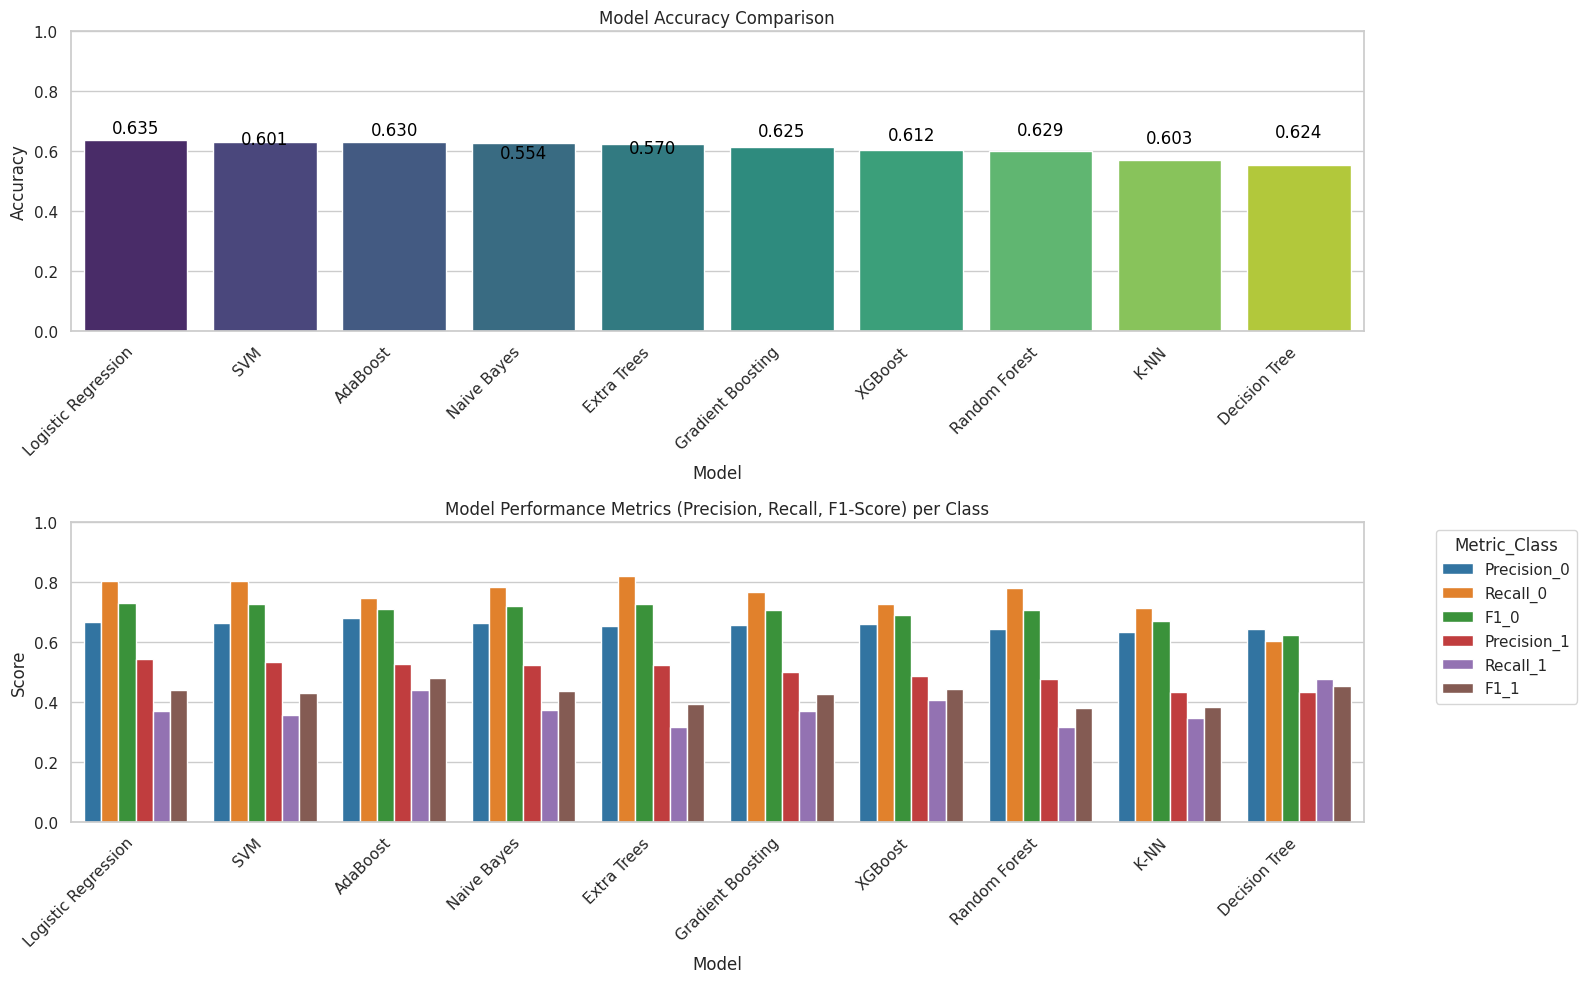


Detailed Performance Metrics per Model:


,Model,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
0,Logistic Regression,0.635179,0.668142,0.803191,0.729469,0.543210,0.369748,0.440000
2,SVM,0.630293,0.663736,0.803191,0.726835,0.534591,0.357143,0.428212
7,AdaBoost,0.628664,0.678744,0.747340,0.711392,0.525000,0.441176,0.479452
5,Naive Bayes,0.625407,0.664414,0.784574,0.719512,0.523529,0.373950,0.436275
9,Extra Trees,0.623779,0.653928,0.819149,0.727273,0.524476,0.315126,0.393701
6,Gradient Boosting,0.612378,0.657534,0.765957,0.707617,0.500000,0.369748,0.425121
8,XGBoost,0.602606,0.659420,0.726064,0.691139,0.485000,0.407563,0.442922
1,Random Forest,0.600977,0.643326,0.781915,0.705882,0.477707,0.315126,0.379747
4,K‑NN,0.570033,0.632075,0.712766,0.670000,0.431579,0.344538,0.383178
3,Decision Tree,0.553746,0.644886,0.603723,0.623626,0.431298,0.474790,0.452000


In [9]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-run the model training and evaluation to capture reports properly if not already done
# (Assuming UBYrIhiboPzw has been run and 'models', 'X_train', 'X_test', 'y_train', 'y_test' are available)

# List to store detailed results (accuracy, precision, recall, f1-score for each class)
de_detailed_results = []

for name, model, X_tr, X_te in models:
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    report = classification_report(y_test, preds, output_dict=True)

    # Extract metrics for class 0 and class 1
    acc = report['accuracy']
    precision_0 = report['0']['precision']
    recall_0 = report['0']['recall']
    f1_0 = report['0']['f1-score']

    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    de_detailed_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision_0': precision_0,
        'Recall_0': recall_0,
        'F1_0': f1_0,
        'Precision_1': precision_1,
        'Recall_1': recall_1,
        'F1_1': f1_1
    })

# Convert to DataFrame
de_detailed_df = pd.DataFrame(de_detailed_results)

# Melt the DataFrame for easier plotting with seaborn
de_melted_df = de_detailed_df.melt(
    id_vars=['Model', 'Accuracy'],
    var_name='Metric_Class',
    value_name='Score'
)

# Separate metric type and class
de_melted_df[['Metric', 'Class']] = de_melted_df['Metric_Class'].str.split('_', expand=True)

# Filter out Accuracy from 'Metric' column to plot separately or combine carefully
de_melted_df_metrics = de_melted_df[de_melted_df['Metric'] != ''].copy()

# Add Accuracy to the melted DataFrame as well, if you want it in the grouped bar chart
# For simplicity, let's keep accuracy separate or add it as a 'general' metric
# For now, let's plot metrics for class 0 and 1 separately for precision, recall, f1

# Plotting
plt.figure(figsize=(16, 10))
sns.set_theme(style="whitegrid")

# Plot Accuracy
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
sns.barplot(x='Model', y='Accuracy', data=de_detailed_df.sort_values('Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in de_detailed_df.sort_values('Accuracy', ascending=False).iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f"{row['Accuracy']:.3f}", color='black', ha="center", va="bottom")

# Plot other metrics for each class in a grouped bar chart
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
sns.barplot(
    data=de_melted_df_metrics.sort_values('Accuracy', ascending=False, key=lambda x: de_melted_df_metrics.loc[x.index, 'Accuracy']),
    x='Model',
    y='Score',
    hue='Metric_Class',
    palette='tab10'
)
plt.title('Model Performance Metrics (Precision, Recall, F1-Score) per Class')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric_Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\nDetailed Performance Metrics per Model:")
display(de_detailed_df.sort_values('Accuracy', ascending=False))

### Applying SMOTE for Class Imbalance

Many real-world datasets suffer from class imbalance, where one class significantly outnumbers the other(s). This can lead to models that perform poorly on the minority class. To address this, we'll use **SMOTE (Synthetic Minority Over-sampling Technique)**, which generates synthetic samples for the minority class, helping to balance the dataset.

**Important Note:** SMOTE should only be applied to the **training data** to prevent data leakage into the test set. We will apply SMOTE to our `X_train` and `y_train` datasets and then re-scale them before re-training our models.

In [10]:
# 1. Load necessary libraries for SMOTE and data processing
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 2. Reload the dataset and perform initial cleaning steps (as done previously)
file_path = "/content/drive/MyDrive/heartdata.xlsx"
df = pd.read_excel(file_path)

df_clean = df.copy()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.drop("heart_disease")
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean = df_clean.drop_duplicates()

X = df_clean.drop(columns=["heart_disease"])
y = df_clean["heart_disease"]

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Original training set class distribution:")
print(y_train.value_counts())

# 4. Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nTraining set class distribution after SMOTE:")
print(y_train_smote.value_counts())

# 5. Scale the SMOTE-transformed training data and the test data
scaler_smote = StandardScaler()
X_train_scaled_smote = scaler_smote.fit_transform(X_train_smote)
X_test_scaled_smote = scaler_smote.transform(X_test)

# 6. Redefine the models list to use SMOTE-transformed data
#    Ensure SVC has probability=True for AUC calculation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

models_smote = [
    ("Logistic Regression", LogisticRegression(max_iter=1000), X_train_scaled_smote, X_test_scaled_smote),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), X_train_smote, X_test),
    ("SVM", SVC(random_state=42, probability=True), X_train_scaled_smote, X_test_scaled_smote), # Added probability=True
    ("Decision Tree", DecisionTreeClassifier(random_state=42), X_train_smote, X_test),
    ("K-NN", KNeighborsClassifier(), X_train_scaled_smote, X_test_scaled_smote),
    ("Naive Bayes", GaussianNB(), X_train_scaled_smote, X_test_scaled_smote),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=42), X_train_smote, X_test),
    ("AdaBoost", AdaBoostClassifier(n_estimators=100, random_state=42), X_train_smote, X_test),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42), X_train_smote, X_test),
    ("Extra Trees", ExtraTreesClassifier(n_estimators=100, random_state=42), X_train_smote, X_test),
]

print("\nData preparation with SMOTE complete. Models list updated.")

Original training set class distribution:
heart_disease
0    1502
1     953
Name: count, dtype: int64

Training set class distribution after SMOTE:
heart_disease
1    1502
0    1502
Name: count, dtype: int64

Data preparation with SMOTE complete. Models list updated.


### Model Training and Evaluation with SMOTE Data

Now, we will train and evaluate all 10 models using the SMOTE-transformed training data. We will collect not only accuracy but also precision, recall, F1-score for both classes, and the Area Under the Receiver Operating Characteristic Curve (AUC) for each model.

In [11]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List to store detailed results including AUC
smote_detailed_results = []

for name, model, X_tr, X_te in models_smote:
    model.fit(X_tr, y_train_smote) # Train with SMOTE-transformed y_train
    preds = model.predict(X_te)
    report = classification_report(y_test, preds, output_dict=True)

    acc = report['accuracy']
    precision_0 = report['0']['precision']
    recall_0 = report['0']['recall']
    f1_0 = report['0']['f1-score']

    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    # Calculate AUC (if model supports predict_proba)
    roc_auc = None
    if hasattr(model, "predict_proba"):
        try:
            y_pred_proba = model.predict_proba(X_te)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
        except AttributeError: # Some models might have predict_proba but it fails (e.g. if not fitted for it)
            pass

    smote_detailed_results.append({
        'Model': name,
        'Accuracy': acc,
        'AUC': roc_auc,
        'Precision_0': precision_0,
        'Recall_0': recall_0,
        'F1_0': f1_0,
        'Precision_1': precision_1,
        'Recall_1': recall_1,
        'F1_1': f1_1
    })
    print(f"\n{'='*50}")
    print(f"{name} (SMOTE)")
    print(f"Accuracy: {acc:.4f}")
    if roc_auc is not None:
        print(f"AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, preds))

# Convert to DataFrame
smote_detailed_df = pd.DataFrame(smote_detailed_results)

print("\n\n" + "="*60)
print("MODEL COMPARISON (ACCURACY & AUC WITH SMOTE)")
print("="*60)
display(smote_detailed_df.sort_values("Accuracy", ascending=False))


Logistic Regression (SMOTE)
Accuracy: 0.6124
AUC: 0.6383
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.64      0.67       376
           1       0.50      0.56      0.53       238

    accuracy                           0.61       614
   macro avg       0.60      0.60      0.60       614
weighted avg       0.62      0.61      0.62       614


Random Forest (SMOTE)
Accuracy: 0.6173
AUC: 0.6314
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       376
           1       0.51      0.46      0.48       238

    accuracy                           0.62       614
   macro avg       0.59      0.59      0.59       614
weighted avg       0.61      0.62      0.61       614


SVM (SMOTE)
Accuracy: 0.6010
AUC: 0.6007
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.68      0.68       376
           1    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:04:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Extra Trees (SMOTE)
Accuracy: 0.6026
AUC: 0.5969
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.72      0.69       376
           1       0.49      0.42      0.45       238

    accuracy                           0.60       614
   macro avg       0.57      0.57      0.57       614
weighted avg       0.59      0.60      0.60       614



MODEL COMPARISON (ACCURACY & AUC WITH SMOTE)


,Model,Accuracy,AUC,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
7,AdaBoost,0.622150,0.641522,0.706897,0.654255,0.679558,0.511278,0.571429,0.539683
1,Random Forest,0.617264,0.631442,0.676692,0.718085,0.696774,0.506977,0.457983,0.481236
6,Gradient Boosting,0.614007,0.631962,0.691460,0.667553,0.679296,0.501992,0.529412,0.515337
0,Logistic Regression,0.612378,0.638287,0.699422,0.643617,0.670360,0.500000,0.563025,0.529644
9,Extra Trees,0.602606,0.596901,0.662562,0.715426,0.687980,0.485577,0.424370,0.452915
2,SVM,0.600977,0.600729,0.672823,0.678191,0.675497,0.485106,0.478992,0.482030
8,XGBoost,0.583062,0.605176,0.661290,0.654255,0.657754,0.462810,0.470588,0.466667
5,Naive Bayes,0.579805,0.600103,0.667614,0.625000,0.645604,0.461832,0.508403,0.484000
3,Decision Tree,0.563518,0.544151,0.647541,0.630319,0.638814,0.439516,0.457983,0.448560
4,K-NN,0.530945,0.536351,0.637500,0.542553,0.586207,0.414966,0.512605,0.458647


### Graphical Comparison of Models (with SMOTE and AUC)

These plots provide a visual summary of how each model performed after applying SMOTE, including their Accuracy, AUC, and detailed precision, recall, and F1-scores for both classes.

### Consolidated Model Comparison Plots (Accuracy, AUC, F1-Scores)

/tmp/ipykernel_28190/3970707023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
/tmp/ipykernel_28190/3970707023.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')
/tmp/ipykernel_28190/3970707023.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1_0', data=smote_detailed_df_sorted, palette='cividis')
/tmp/ipykernel_28190/3970707023.py:44: FutureWarning: 

Passing `palette` with

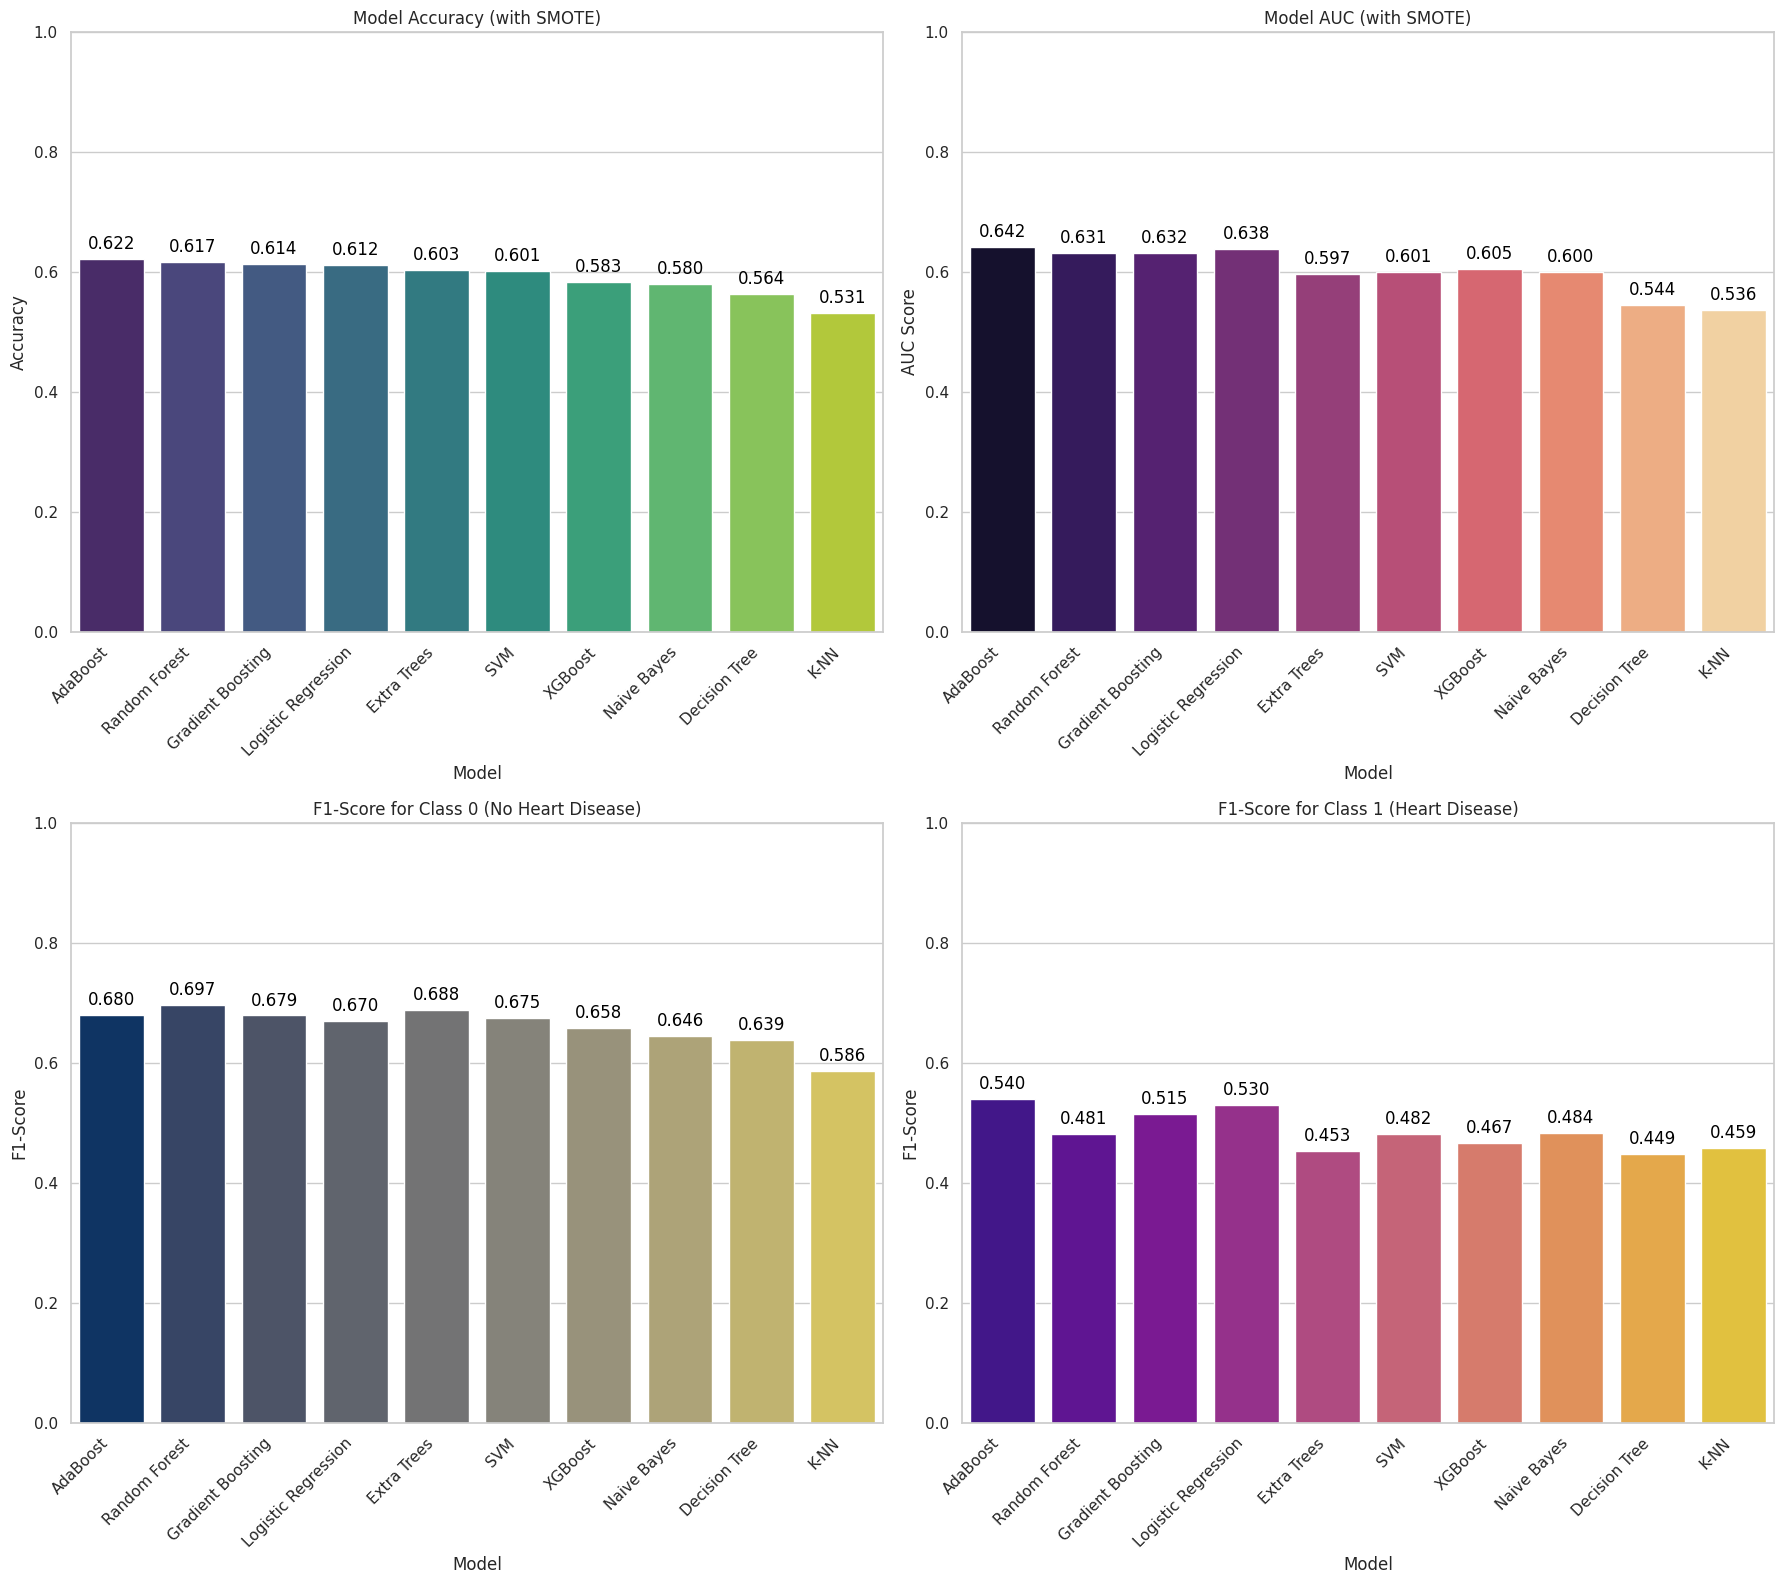

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure smote_detailed_df is sorted by accuracy for consistent plotting
smote_detailed_df_sorted = smote_detailed_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(18, 16)) # Increased figure size for 2x2 grid
sns.set_theme(style="whitegrid")

# --- Plot 1: Accuracy Comparison ---
plt.subplot(2, 2, 1) # 2 rows, 2 columns, first plot
sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
plt.title('Model Accuracy (with SMOTE)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['Accuracy'] + 0.01, f"{row[1]['Accuracy']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 2: AUC Comparison ---
plt.subplot(2, 2, 2) # 2 rows, 2 columns, second plot
sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')
plt.title('Model AUC (with SMOTE)')
plt.ylabel('AUC Score')
plt.ylim(0, 1) # AUC is between 0 and 1
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    if pd.notna(row[1]['AUC']): # Only annotate if AUC is not NaN
        plt.text(index, row[1]['AUC'] + 0.01, f"{row[1]['AUC']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 3: F1-Score for Class 0 ---
plt.subplot(2, 2, 3) # 2 rows, 2 columns, third plot
sns.barplot(x='Model', y='F1_0', data=smote_detailed_df_sorted, palette='cividis')
plt.title('F1-Score for Class 0 (No Heart Disease)')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['F1_0'] + 0.01, f"{row[1]['F1_0']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 4: F1-Score for Class 1 ---
plt.subplot(2, 2, 4) # 2 rows, 2 columns, fourth plot
sns.barplot(x='Model', y='F1_1', data=smote_detailed_df_sorted, palette='plasma')
plt.title('F1-Score for Class 1 (Heart Disease)')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['F1_1'] + 0.01, f"{row[1]['F1_1']:.3f}", color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

/tmp/ipykernel_28190/3970707023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
/tmp/ipykernel_28190/3970707023.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')
/tmp/ipykernel_28190/3970707023.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1_0', data=smote_detailed_df_sorted, palette='cividis')
/tmp/ipykernel_28190/3970707023.py:44: FutureWarning: 

Passing `palette` with

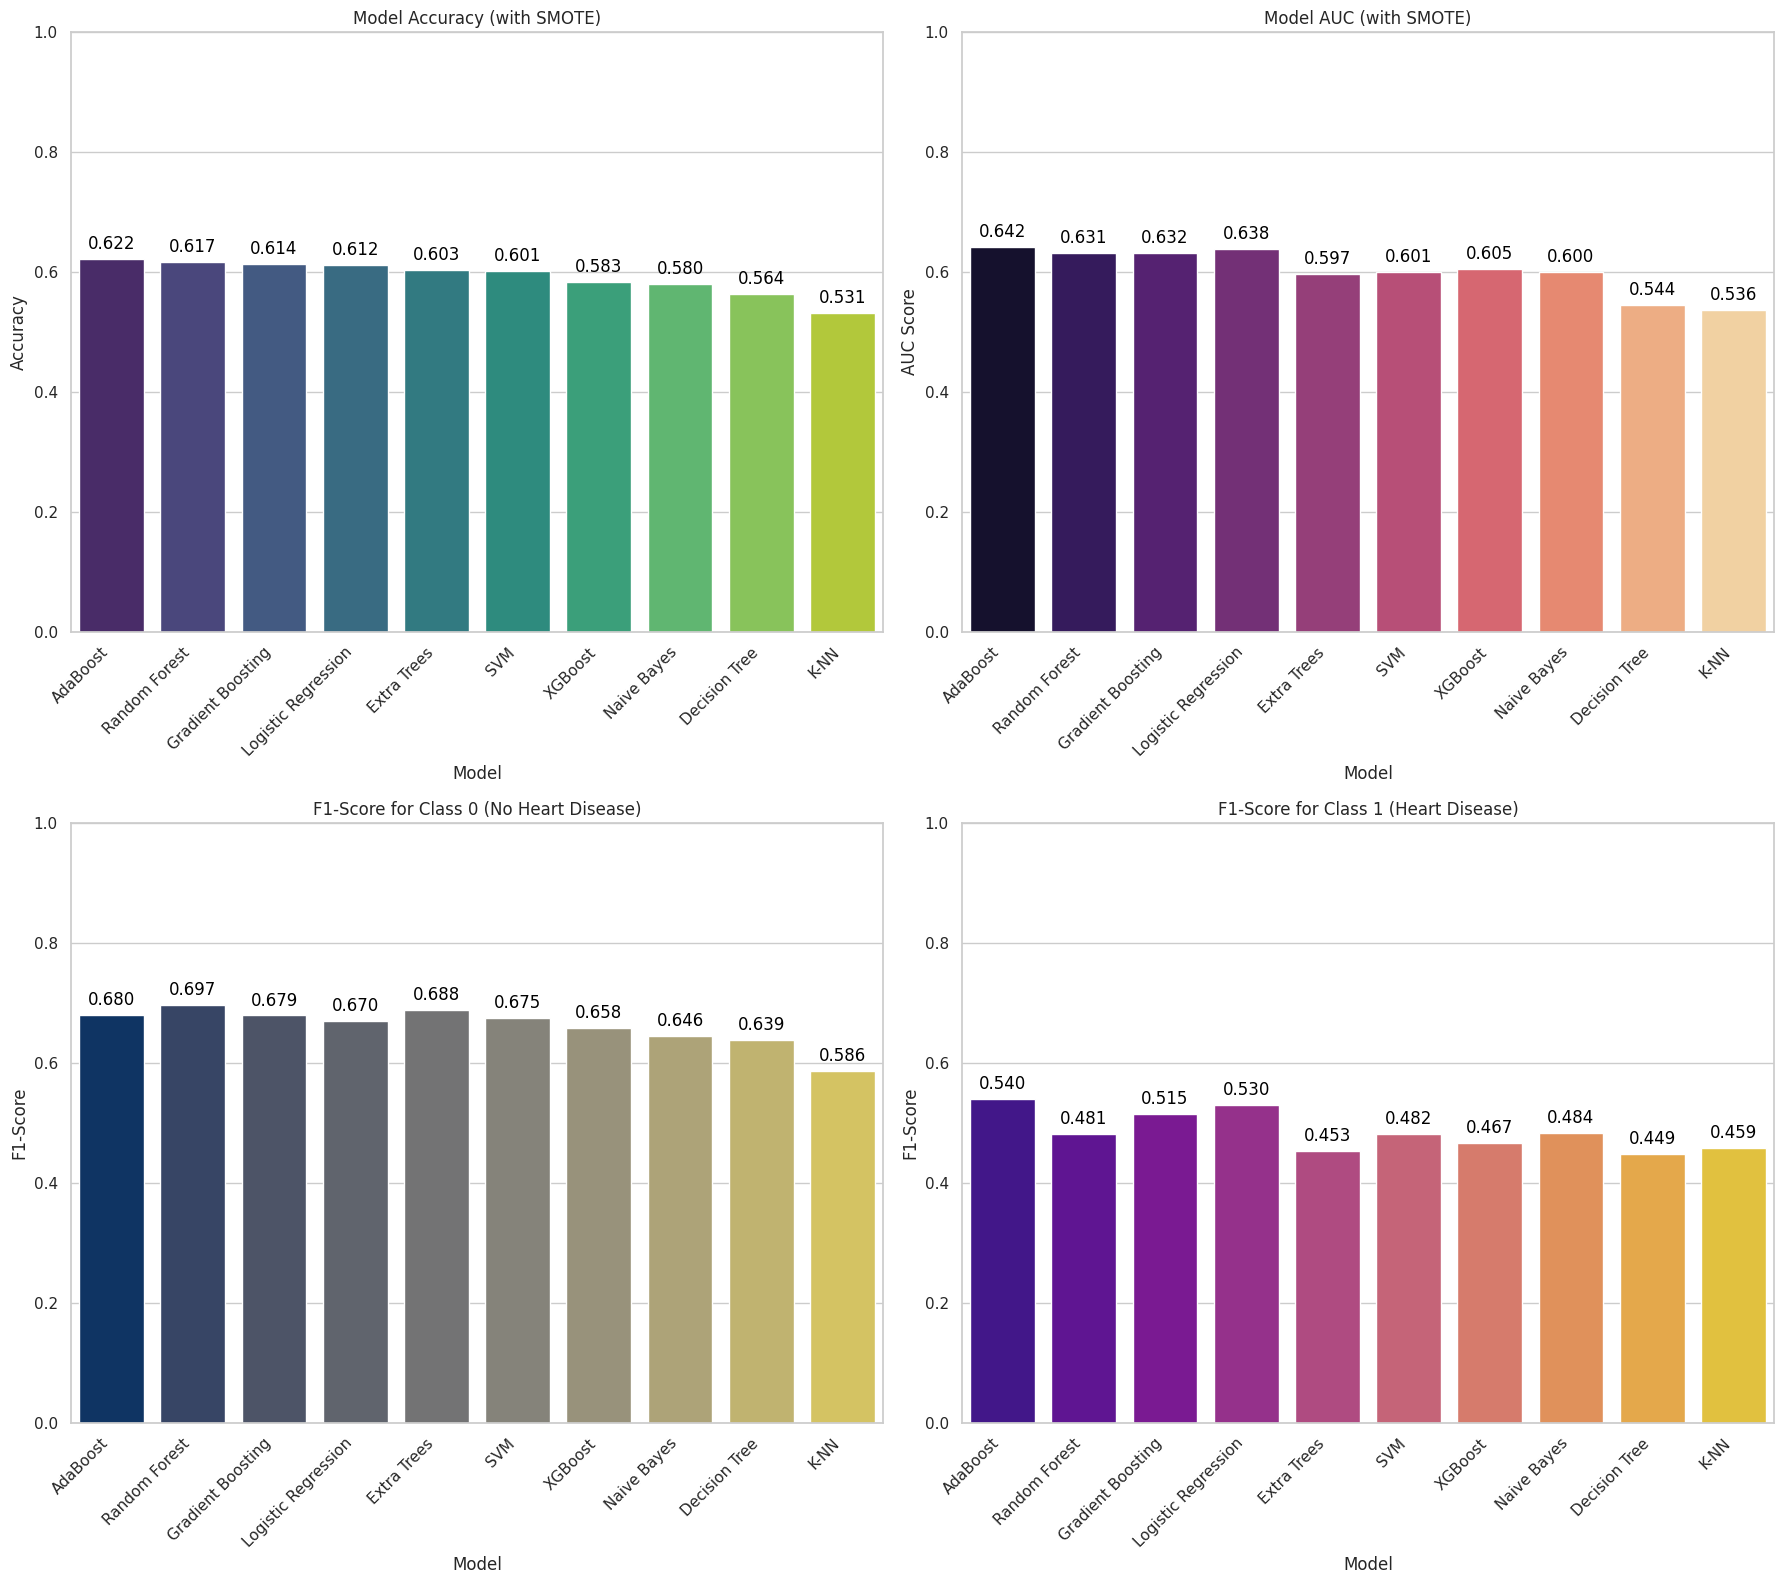

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure smote_detailed_df is sorted by accuracy for consistent plotting
smote_detailed_df_sorted = smote_detailed_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(18, 16)) # Increased figure size for 2x2 grid
sns.set_theme(style="whitegrid")

# --- Plot 1: Accuracy Comparison ---
plt.subplot(2, 2, 1) # 2 rows, 2 columns, first plot
sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
plt.title('Model Accuracy (with SMOTE)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['Accuracy'] + 0.01, f"{row[1]['Accuracy']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 2: AUC Comparison ---
plt.subplot(2, 2, 2) # 2 rows, 2 columns, second plot
sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')
plt.title('Model AUC (with SMOTE)')
plt.ylabel('AUC Score')
plt.ylim(0, 1) # AUC is between 0 and 1
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    if pd.notna(row[1]['AUC']): # Only annotate if AUC is not NaN
        plt.text(index, row[1]['AUC'] + 0.01, f"{row[1]['AUC']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 3: F1-Score for Class 0 ---
plt.subplot(2, 2, 3) # 2 rows, 2 columns, third plot
sns.barplot(x='Model', y='F1_0', data=smote_detailed_df_sorted, palette='cividis')
plt.title('F1-Score for Class 0 (No Heart Disease)')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['F1_0'] + 0.01, f"{row[1]['F1_0']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 4: F1-Score for Class 1 ---
plt.subplot(2, 2, 4) # 2 rows, 2 columns, fourth plot
sns.barplot(x='Model', y='F1_1', data=smote_detailed_df_sorted, palette='plasma')
plt.title('F1-Score for Class 1 (Heart Disease)')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['F1_1'] + 0.01, f"{row[1]['F1_1']:.3f}", color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()

/tmp/ipykernel_28190/1402858978.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
/tmp/ipykernel_28190/1402858978.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')


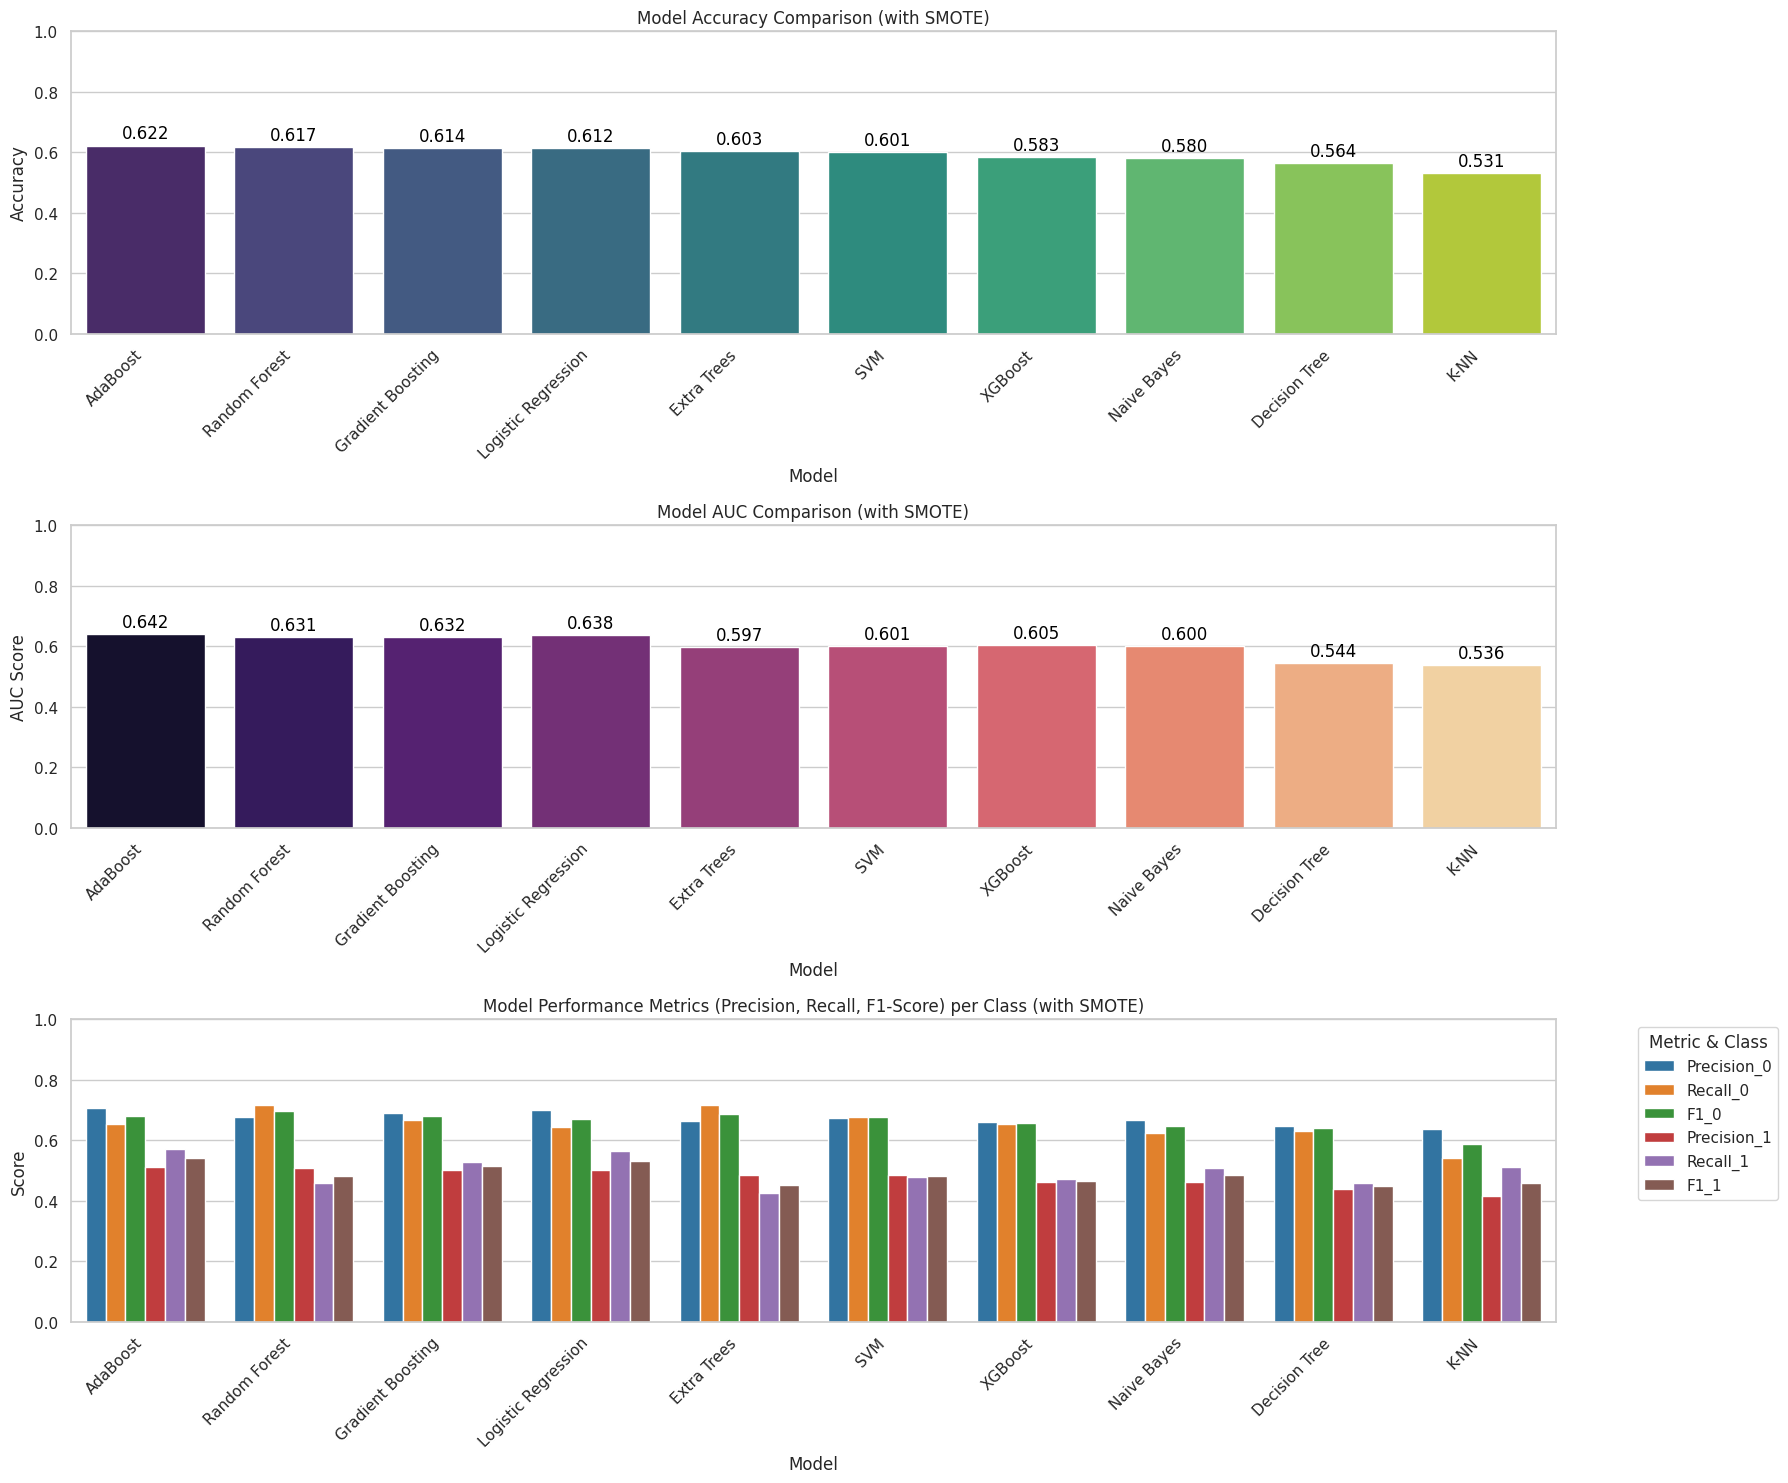


Detailed Performance Metrics per Model after SMOTE:


,Model,Accuracy,AUC,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
7,AdaBoost,0.622150,0.641522,0.706897,0.654255,0.679558,0.511278,0.571429,0.539683
1,Random Forest,0.617264,0.631442,0.676692,0.718085,0.696774,0.506977,0.457983,0.481236
6,Gradient Boosting,0.614007,0.631962,0.691460,0.667553,0.679296,0.501992,0.529412,0.515337
0,Logistic Regression,0.612378,0.638287,0.699422,0.643617,0.670360,0.500000,0.563025,0.529644
9,Extra Trees,0.602606,0.596901,0.662562,0.715426,0.687980,0.485577,0.424370,0.452915
2,SVM,0.600977,0.600729,0.672823,0.678191,0.675497,0.485106,0.478992,0.482030
8,XGBoost,0.583062,0.605176,0.661290,0.654255,0.657754,0.462810,0.470588,0.466667
5,Naive Bayes,0.579805,0.600103,0.667614,0.625000,0.645604,0.461832,0.508403,0.484000
3,Decision Tree,0.563518,0.544151,0.647541,0.630319,0.638814,0.439516,0.457983,0.448560
4,K-NN,0.530945,0.536351,0.637500,0.542553,0.586207,0.414966,0.512605,0.458647


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure smote_detailed_df is sorted by accuracy for consistent plotting
smote_detailed_df_sorted = smote_detailed_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(18, 15))
sns.set_theme(style="whitegrid")

# --- Plot 1: Accuracy Comparison ---
plt.subplot(3, 1, 1) # 3 rows, 1 column, first plot
sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
plt.title('Model Accuracy Comparison (with SMOTE)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['Accuracy'] + 0.01, f"{row[1]['Accuracy']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 2: AUC Comparison ---
plt.subplot(3, 1, 2) # 3 rows, 1 column, second plot
sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')
plt.title('Model AUC Comparison (with SMOTE)')
plt.ylabel('AUC Score')
plt.ylim(0, 1) # AUC is between 0 and 1
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    if pd.notna(row[1]['AUC']): # Only annotate if AUC is not NaN
        plt.text(index, row[1]['AUC'] + 0.01, f"{row[1]['AUC']:.3f}", color='black', ha="center", va="bottom")

# --- Plot 3: Other Metrics (Precision, Recall, F1) per Class ---
# Melt the DataFrame for easier plotting with seaborn for the other metrics
metrics_to_melt = ['Precision_0', 'Recall_0', 'F1_0', 'Precision_1', 'Recall_1', 'F1_1']
smote_melted_df_metrics = smote_detailed_df_sorted.melt(
    id_vars=['Model'],
    value_vars=metrics_to_melt,
    var_name='Metric_Class',
    value_name='Score'
)

plt.subplot(3, 1, 3) # 3 rows, 1 column, third plot
sns.barplot(
    data=smote_melted_df_metrics,
    x='Model',
    y='Score',
    hue='Metric_Class',
    palette='tab10'
)
plt.title('Model Performance Metrics (Precision, Recall, F1-Score) per Class (with SMOTE)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric & Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\nDetailed Performance Metrics per Model after SMOTE:")
display(smote_detailed_df_sorted)

### Impact of SMOTE on Model Performance

In [15]:
import pandas as pd

# Prepare the dataframes for comparison
# Rename columns of the non-SMOTE dataframe to avoid conflicts and indicate 'without SMOTE'
non_smote_df = de_detailed_df.copy()
non_smote_df = non_smote_df.rename(columns={
    'Accuracy': 'Accuracy_NoSMOTE',
    'F1_0': 'F1_0_NoSMOTE',
    'F1_1': 'F1_1_NoSMOTE'
})

# Select relevant columns from SMOTE dataframe
smote_df_for_comp = smote_detailed_df[['Model', 'Accuracy', 'AUC', 'F1_0', 'F1_1']].copy()
smote_df_for_comp = smote_df_for_comp.rename(columns={
    'Accuracy': 'Accuracy_WithSMOTE',
    'F1_0': 'F1_0_WithSMOTE',
    'F1_1': 'F1_1_WithSMOTE'
})

# Merge the two dataframes on the 'Model' column
comparison_df = pd.merge(non_smote_df, smote_df_for_comp, on='Model', how='inner')

# Calculate the differences
comparison_df['Accuracy_Difference'] = comparison_df['Accuracy_WithSMOTE'] - comparison_df['Accuracy_NoSMOTE']
comparison_df['F1_0_Difference'] = comparison_df['F1_0_WithSMOTE'] - comparison_df['F1_0_NoSMOTE']
comparison_df['F1_1_Difference'] = comparison_df['F1_1_WithSMOTE'] - comparison_df['F1_1_NoSMOTE']

# Display the comparison table, sorted by the impact on overall accuracy
print("\nModel Performance Differences (With SMOTE vs. Without SMOTE):")
display(comparison_df[[
    'Model',
    'Accuracy_NoSMOTE', 'Accuracy_WithSMOTE', 'Accuracy_Difference',
    'F1_0_NoSMOTE', 'F1_0_WithSMOTE', 'F1_0_Difference',
    'F1_1_NoSMOTE', 'F1_1_WithSMOTE', 'F1_1_Difference'
]].sort_values('Accuracy_Difference', ascending=False))

print("\nSummary of SMOTE Impact:")
print(comparison_df[['Accuracy_Difference', 'F1_0_Difference', 'F1_1_Difference']].describe())


Model Performance Differences (With SMOTE vs. Without SMOTE):


,Model,Accuracy_NoSMOTE,Accuracy_WithSMOTE,Accuracy_Difference,F1_0_NoSMOTE,F1_0_WithSMOTE,F1_0_Difference,F1_1_NoSMOTE,F1_1_WithSMOTE,F1_1_Difference
1,Random Forest,0.600977,0.617264,0.016287,0.705882,0.696774,-0.009108,0.379747,0.481236,0.101489
3,Decision Tree,0.553746,0.563518,0.009772,0.623626,0.638814,0.015188,0.452000,0.448560,-0.003440
5,Gradient Boosting,0.612378,0.614007,0.001629,0.707617,0.679296,-0.028320,0.425121,0.515337,0.090217
6,AdaBoost,0.628664,0.622150,-0.006515,0.711392,0.679558,-0.031834,0.479452,0.539683,0.060230
7,XGBoost,0.602606,0.583062,-0.019544,0.691139,0.657754,-0.033385,0.442922,0.466667,0.023744
8,Extra Trees,0.623779,0.602606,-0.021173,0.727273,0.687980,-0.039293,0.393701,0.452915,0.059214
0,Logistic Regression,0.635179,0.612378,-0.022801,0.729469,0.670360,-0.059108,0.440000,0.529644,0.089644
2,SVM,0.630293,0.600977,-0.029316,0.726835,0.675497,-0.051338,0.428212,0.482030,0.053818
4,Naive Bayes,0.625407,0.579805,-0.045603,0.719512,0.645604,-0.073908,0.436275,0.484000,0.047725



Summary of SMOTE Impact:
       Accuracy_Difference  F1_0_Difference  F1_1_Difference
count             9.000000         9.000000         9.000000
mean             -0.013029        -0.034568         0.058071
std               0.019897         0.026517         0.033557
min              -0.045603        -0.073908        -0.003440
25%              -0.022801        -0.051338         0.047725
50%              -0.019544        -0.033385         0.059214
75%               0.001629        -0.028320         0.089644
max               0.016287         0.015188         0.101489


In [16]:
import os

# Create a directory to save outputs if it doesn't exist
output_dir = 'saved_outputs'
os.makedirs(output_dir, exist_ok=True)

# Save the detailed performance DataFrame to CSV
smote_detailed_df.to_csv(os.path.join(output_dir, 'smote_model_performance_metrics.csv'), index=False)
print(f"Detailed performance metrics saved to {output_dir}/smote_model_performance_metrics.csv")

Detailed performance metrics saved to saved_outputs/smote_model_performance_metrics.csv


And now, a cell to save the plots. This code will regenerate the plots and save them individually to the 'saved_outputs' folder.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Ensure smote_detailed_df is sorted by accuracy for consistent plotting
smote_detailed_df_sorted = smote_detailed_df.sort_values('Accuracy', ascending=False)

# Create a directory to save outputs if it doesn't exist
output_dir = 'saved_outputs'
os.makedirs(output_dir, exist_ok=True)

# --- Plot 1: Accuracy Comparison ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')
plt.title('Model Accuracy (with SMOTE)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['Accuracy'] + 0.01, f"{row[1]['Accuracy']:.3f}", color='black', ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'smote_accuracy_comparison.png'))
print(f"Accuracy plot saved to {output_dir}/smote_accuracy_comparison.png")
plt.close() # Close the plot to free memory

# --- Plot 2: AUC Comparison ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')
plt.title('Model AUC (with SMOTE)')
plt.ylabel('AUC Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    if pd.notna(row[1]['AUC']):
        plt.text(index, row[1]['AUC'] + 0.01, f"{row[1]['AUC']:.3f}", color='black', ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'smote_auc_comparison.png'))
print(f"AUC plot saved to {output_dir}/smote_auc_comparison.png")
plt.close()

# --- Plot 3: F1-Score for Class 0 ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(x='Model', y='F1_0', data=smote_detailed_df_sorted, palette='cividis')
plt.title('F1-Score for Class 0 (No Heart Disease)')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['F1_0'] + 0.01, f"{row[1]['F1_0']:.3f}", color='black', ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'smote_f1_class0_comparison.png'))
print(f"F1-Score Class 0 plot saved to {output_dir}/smote_f1_class0_comparison.png")
plt.close()

# --- Plot 4: F1-Score for Class 1 ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.barplot(x='Model', y='F1_1', data=smote_detailed_df_sorted, palette='plasma')
plt.title('F1-Score for Class 1 (Heart Disease)')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index, row in enumerate(smote_detailed_df_sorted.iterrows()):
    plt.text(index, row[1]['F1_1'] + 0.01, f"{row[1]['F1_1']:.3f}", color='black', ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'smote_f1_class1_comparison.png'))
print(f"F1-Score Class 1 plot saved to {output_dir}/smote_f1_class1_comparison.png")
plt.close()

/tmp/ipykernel_28190/2214448385.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=smote_detailed_df_sorted, palette='viridis')


Accuracy plot saved to saved_outputs/smote_accuracy_comparison.png


/tmp/ipykernel_28190/2214448385.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=smote_detailed_df_sorted, palette='magma')


AUC plot saved to saved_outputs/smote_auc_comparison.png


/tmp/ipykernel_28190/2214448385.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1_0', data=smote_detailed_df_sorted, palette='cividis')


F1-Score Class 0 plot saved to saved_outputs/smote_f1_class0_comparison.png


/tmp/ipykernel_28190/2214448385.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1_1', data=smote_detailed_df_sorted, palette='plasma')


F1-Score Class 1 plot saved to saved_outputs/smote_f1_class1_comparison.png
